# PART 1: Steps 1-4


## Step 1: Data Loading & EDA
Load CSV into pandas. Plot class distribution, correlation heatmap, boxplots of key features by class.
## Step 2: Preprocessing
Impute missing values (median for numeric, mode for categorical). One-hot encode categoricals. Apply StandardScaler to numeric features.
## Step 3: Model Training
Train Logistic Regression, Decision Tree, Random Forest. Use StratifiedKFold (5-fold) for cross-validation. Tune max_depth and n_estimators.
## Step 4: Evaluation
Report classification report, confusion matrix, AUC-ROC curve. Plot feature importances from Random Forest.


## SECTION 0: INSTALLATION & IMPORTS

In [ ]:
!pip install pandas numpy matplotlib seaborn scikit-learn imbalanced-learn shap plotly -q

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Sklearn imports
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, roc_curve)

# Imbalanced learning
from imblearn.over_sampling import SMOTE

# SHAP for interpretability
import shap

# Utilities
import pickle
import warnings
warnings.filterwarnings('ignore')

# Plotting settings
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

print("✅ All libraries imported successfully!")
print("="*80)

✅ All libraries imported successfully!


## STEP 1: DATA LOADING & EXPLORATORY DATA ANALYSIS (EDA)


STEP 1: DATA LOADING & EXPLORATORY DATA ANALYSIS

📁 Please upload your data.csv file:


Saving data.csv to data.csv

--------------------------------------------------------------------------------
1.1 DATASET OVERVIEW
--------------------------------------------------------------------------------
Dataset Shape: (4424, 37)
Total Rows: 4,424
Total Columns: 37

Column Names:
   1. Marital status
   2. Application mode
   3. Application order
   4. Course
   5. Daytime/evening attendance	
   6. Previous qualification
   7. Previous qualification (grade)
   8. Nacionality
   9. Mother's qualification
  10. Father's qualification
  11. Mother's occupation
  12. Father's occupation
  13. Admission grade
  14. Displaced
  15. Educational special needs
  16. Debtor
  17. Tuition fees up to date
  18. Gender
  19. Scholarship holder
  20. Age at enrollment
  21. International
  22. Curricular units 1st sem (credited)
  23. Curricular units 1st sem (enrolled)
  24. Curricular units 1st sem (evaluations)
  25. Curricular units 1st sem (approved)
  26. Curricular units 1st sem (grad

,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,Mother's occupation,Father's occupation,Admission grade,Displaced,Educational special needs,Debtor,Tuition fees up to date,Gender,Scholarship holder,Age at enrollment,International,Curricular units 1st sem (credited),Curricular units 1st sem (enrolled),Curricular units 1st sem (evaluations),Curricular units 1st sem (approved),Curricular units 1st sem (grade),Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,5,9,127.3,1,0,0,1,1,0,20,0,0,0,0,0,0.000000,0,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,3,3,142.5,1,0,0,0,1,0,19,0,0,6,6,6,14.000000,0,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,9,9,124.8,1,0,0,0,1,0,19,0,0,6,0,0,0.000000,0,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,5,3,119.6,1,0,0,1,0,0,20,0,0,6,8,6,13.428571,0,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,9,9,141.5,0,0,0,1,0,0,45,0,0,6,9,5,12.333333,0,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate



--------------------------------------------------------------------------------
1.3 DATA TYPES & INFO
--------------------------------------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance	                     4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Previous qualification (grade)                  4424 non-null   float64
 7   Nacionalit

,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,Mother's occupation,Father's occupation,Admission grade,Displaced,Educational special needs,Debtor,Tuition fees up to date,Gender,Scholarship holder,Age at enrollment,International,Curricular units 1st sem (credited),Curricular units 1st sem (enrolled),Curricular units 1st sem (evaluations),Curricular units 1st sem (approved),Curricular units 1st sem (grade),Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP
count,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000
mean,1.178571,18.669078,1.727848,8856.642631,0.890823,4.577758,132.613314,1.873192,19.561935,22.275316,10.960895,11.032324,126.978119,0.548373,0.011528,0.113698,0.880651,0.351718,0.248418,23.265145,0.024864,0.709991,6.270570,8.299051,4.706600,10.640822,0.137658,0.541817,6.232143,8.063291,4.435805,10.230206,0.150316,11.566139,1.228029,0.001969
std,0.605747,17.484682,1.313793,2063.566416,0.311897,10.216592,13.188332,6.914514,15.603186,15.343108,26.418253,25.263040,14.482001,0.497711,0.106760,0.317480,0.324235,0.477560,0.432144,7.587816,0.155729,2.360507,2.480178,4.179106,3.094238,4.843663,0.690880,1.918546,2.195951,3.947951,3.014764,5.210808,0.753774,2.663850,1.382711,2.269935
min,1.000000,1.000000,0.000000,33.000000,0.000000,1.000000,95.000000,1.000000,1.000000,1.000000,0.000000,0.000000,95.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,17.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,7.600000,-0.800000,-4.060000
25%,1.000000,1.000000,1.000000,9085.000000,1.000000,1.000000,125.000000,1.000000,2.000000,3.000000,4.000000,4.000000,117.900000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,19.000000,0.000000,0.000000,5.000000,6.000000,3.000000,11.000000,0.000000,0.000000,5.000000,6.000000,2.000000,10.750000,0.000000,9.400000,0.300000,-1.700000
50%,1.000000,17.000000,1.000000,9238.000000,1.000000,1.000000,133.100000,1.000000,19.000000,19.000000,5.000000,7.000000,126.100000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,20.000000,0.000000,0.000000,6.000000,8.000000,5.000000,12.285714,0.000000,0.000000,6.000000,8.000000,5.000000,12.200000,0.000000,11.100000,1.400000,0.320000
75%,1.000000,39.000000,2.000000,9556.000000,1.000000,1.000000,140.000000,1.000000,37.000000,37.000000,9.000000,9.000000,134.800000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,25.000000,0.000000,0.000000,7.000000,10.000000,6.000000,13.400000,0.000000,0.000000,7.000000,10.000000,6.000000,13.333333,0.000000,13.900000,2.600000,1.790000
max,6.000000,57.000000,9.000000,9991.000000,1.000000,43.000000,190.000000,109.000000,44.000000,44.000000,194.000000,195.000000,190.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,70.000000,1.000000,20.000000,26.000000,45.000000,26.000000,18.875000,12.000000,19.000000,23.000000,33.000000,20.000000,18.571429,12.000000,16.200000,3.700000,3.510000



--------------------------------------------------------------------------------
1.5 MISSING VALUES ANALYSIS
--------------------------------------------------------------------------------
✅ No missing values found in the dataset!

--------------------------------------------------------------------------------
1.6 TARGET VARIABLE ANALYSIS
--------------------------------------------------------------------------------

Original Target Distribution:
Target
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64

Target Percentages:
Target
Graduate    49.93
Dropout     32.12
Enrolled    17.95
Name: count, dtype: float64

Binary Target Distribution:
Non-Dropout (0): 3,003 (67.88%)
Dropout (1): 1,421 (32.12%)


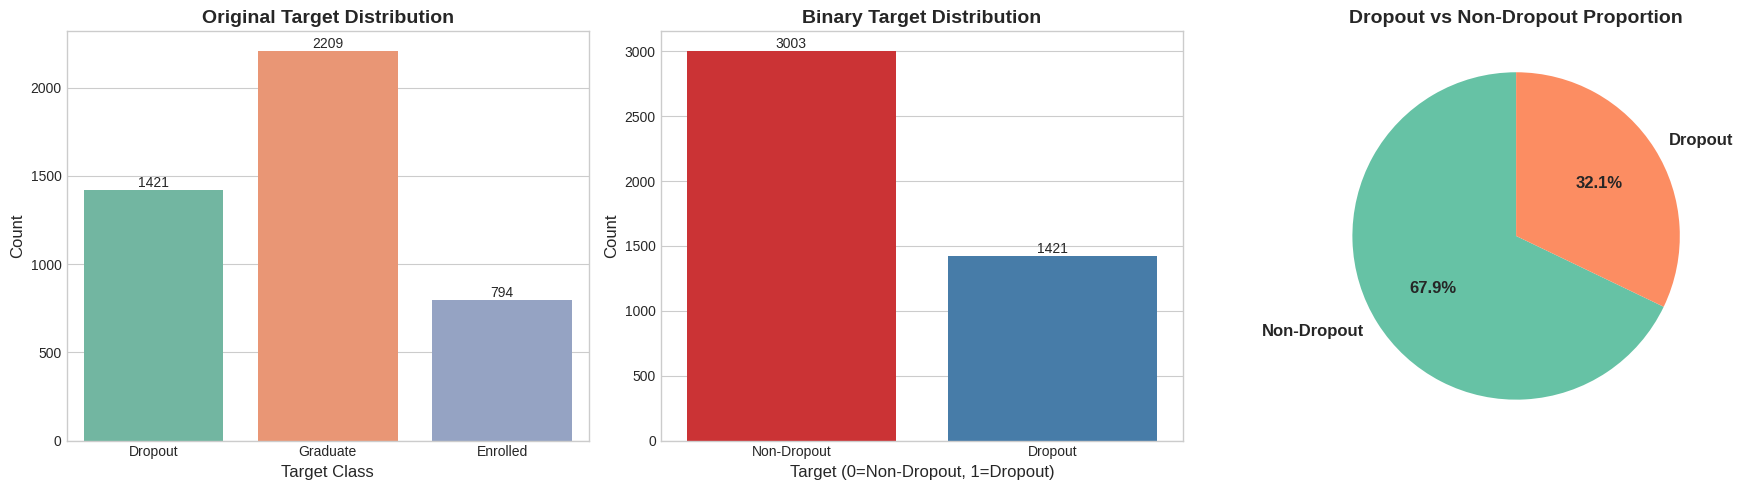


📊 Class Imbalance Ratio: 2.11:1
⚠️  WARNING: Significant class imbalance detected!
   → Will apply SMOTE oversampling during training

--------------------------------------------------------------------------------
1.7 FEATURE TYPE IDENTIFICATION
--------------------------------------------------------------------------------

📊 Numerical Features (36):
   1. Marital status
   2. Application mode
   3. Application order
   4. Course
   5. Daytime/evening attendance	
   6. Previous qualification
   7. Previous qualification (grade)
   8. Nacionality
   9. Mother's qualification
  10. Father's qualification
  11. Mother's occupation
  12. Father's occupation
  13. Admission grade
  14. Displaced
  15. Educational special needs
  16. Debtor
  17. Tuition fees up to date
  18. Gender
  19. Scholarship holder
  20. Age at enrollment
  21. International
  22. Curricular units 1st sem (credited)
  23. Curricular units 1st sem (enrolled)
  24. Curricular units 1st sem (evaluations)
  25. Cur

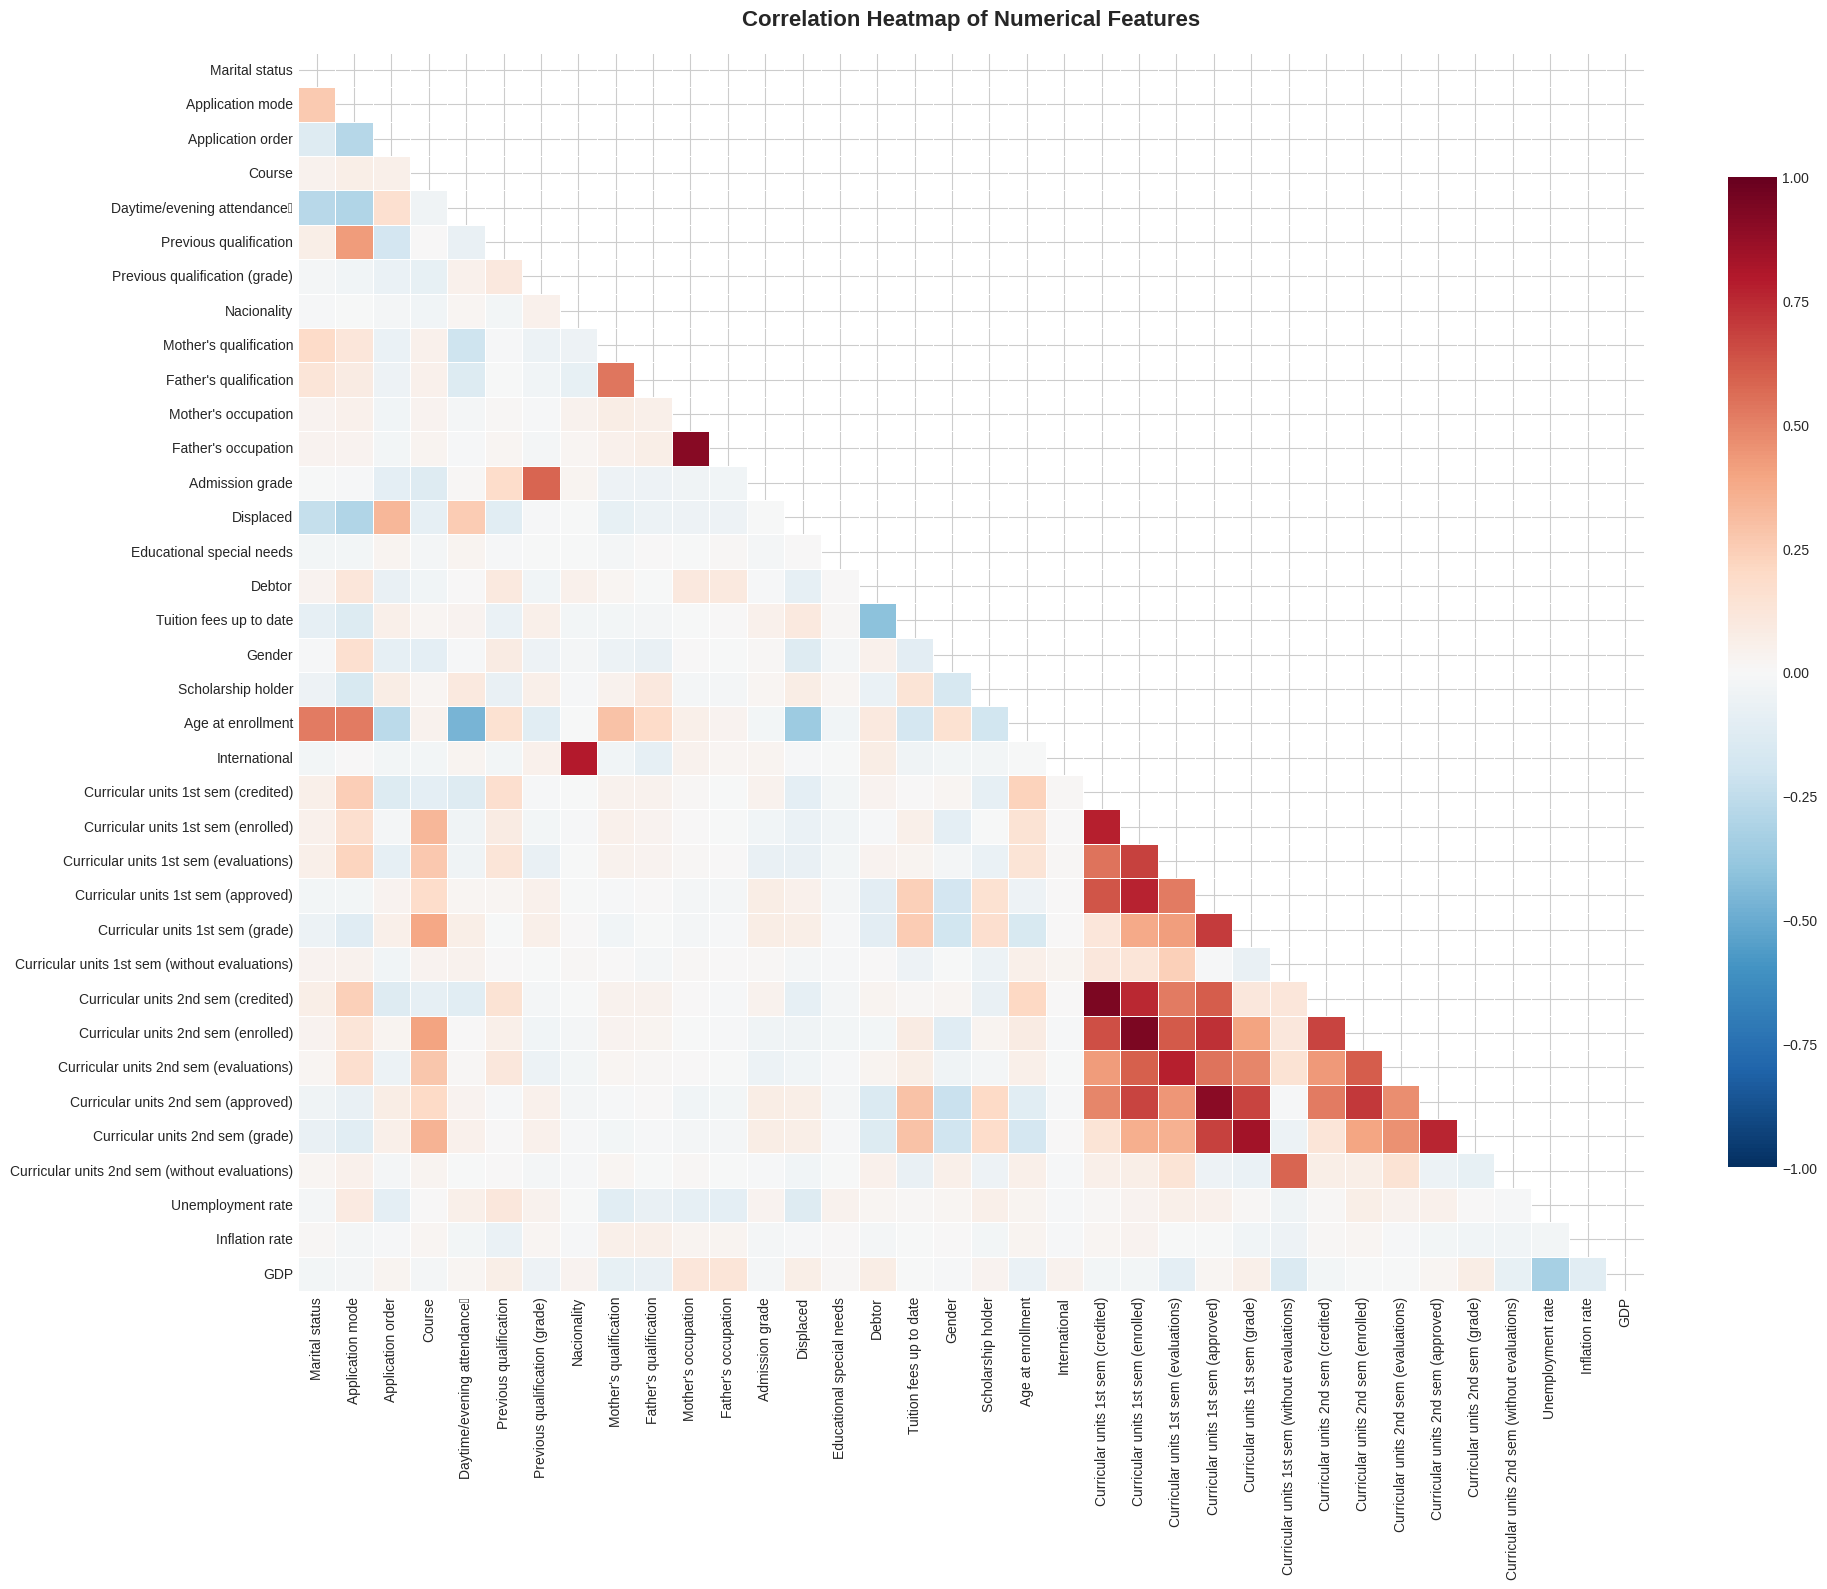


🔍 Highly Correlated Feature Pairs (|correlation| > 0.8):


,Feature_1,Feature_2,Correlation
1,Curricular units 1st sem (credited),Curricular units 2nd sem (credited),0.945
2,Curricular units 1st sem (enrolled),Curricular units 2nd sem (enrolled),0.943
0,Mother's occupation,Father's occupation,0.910
3,Curricular units 1st sem (approved),Curricular units 2nd sem (approved),0.904
4,Curricular units 1st sem (grade),Curricular units 2nd sem (grade),0.837



--------------------------------------------------------------------------------
1.9 KEY FEATURE DISTRIBUTIONS BY TARGET
--------------------------------------------------------------------------------


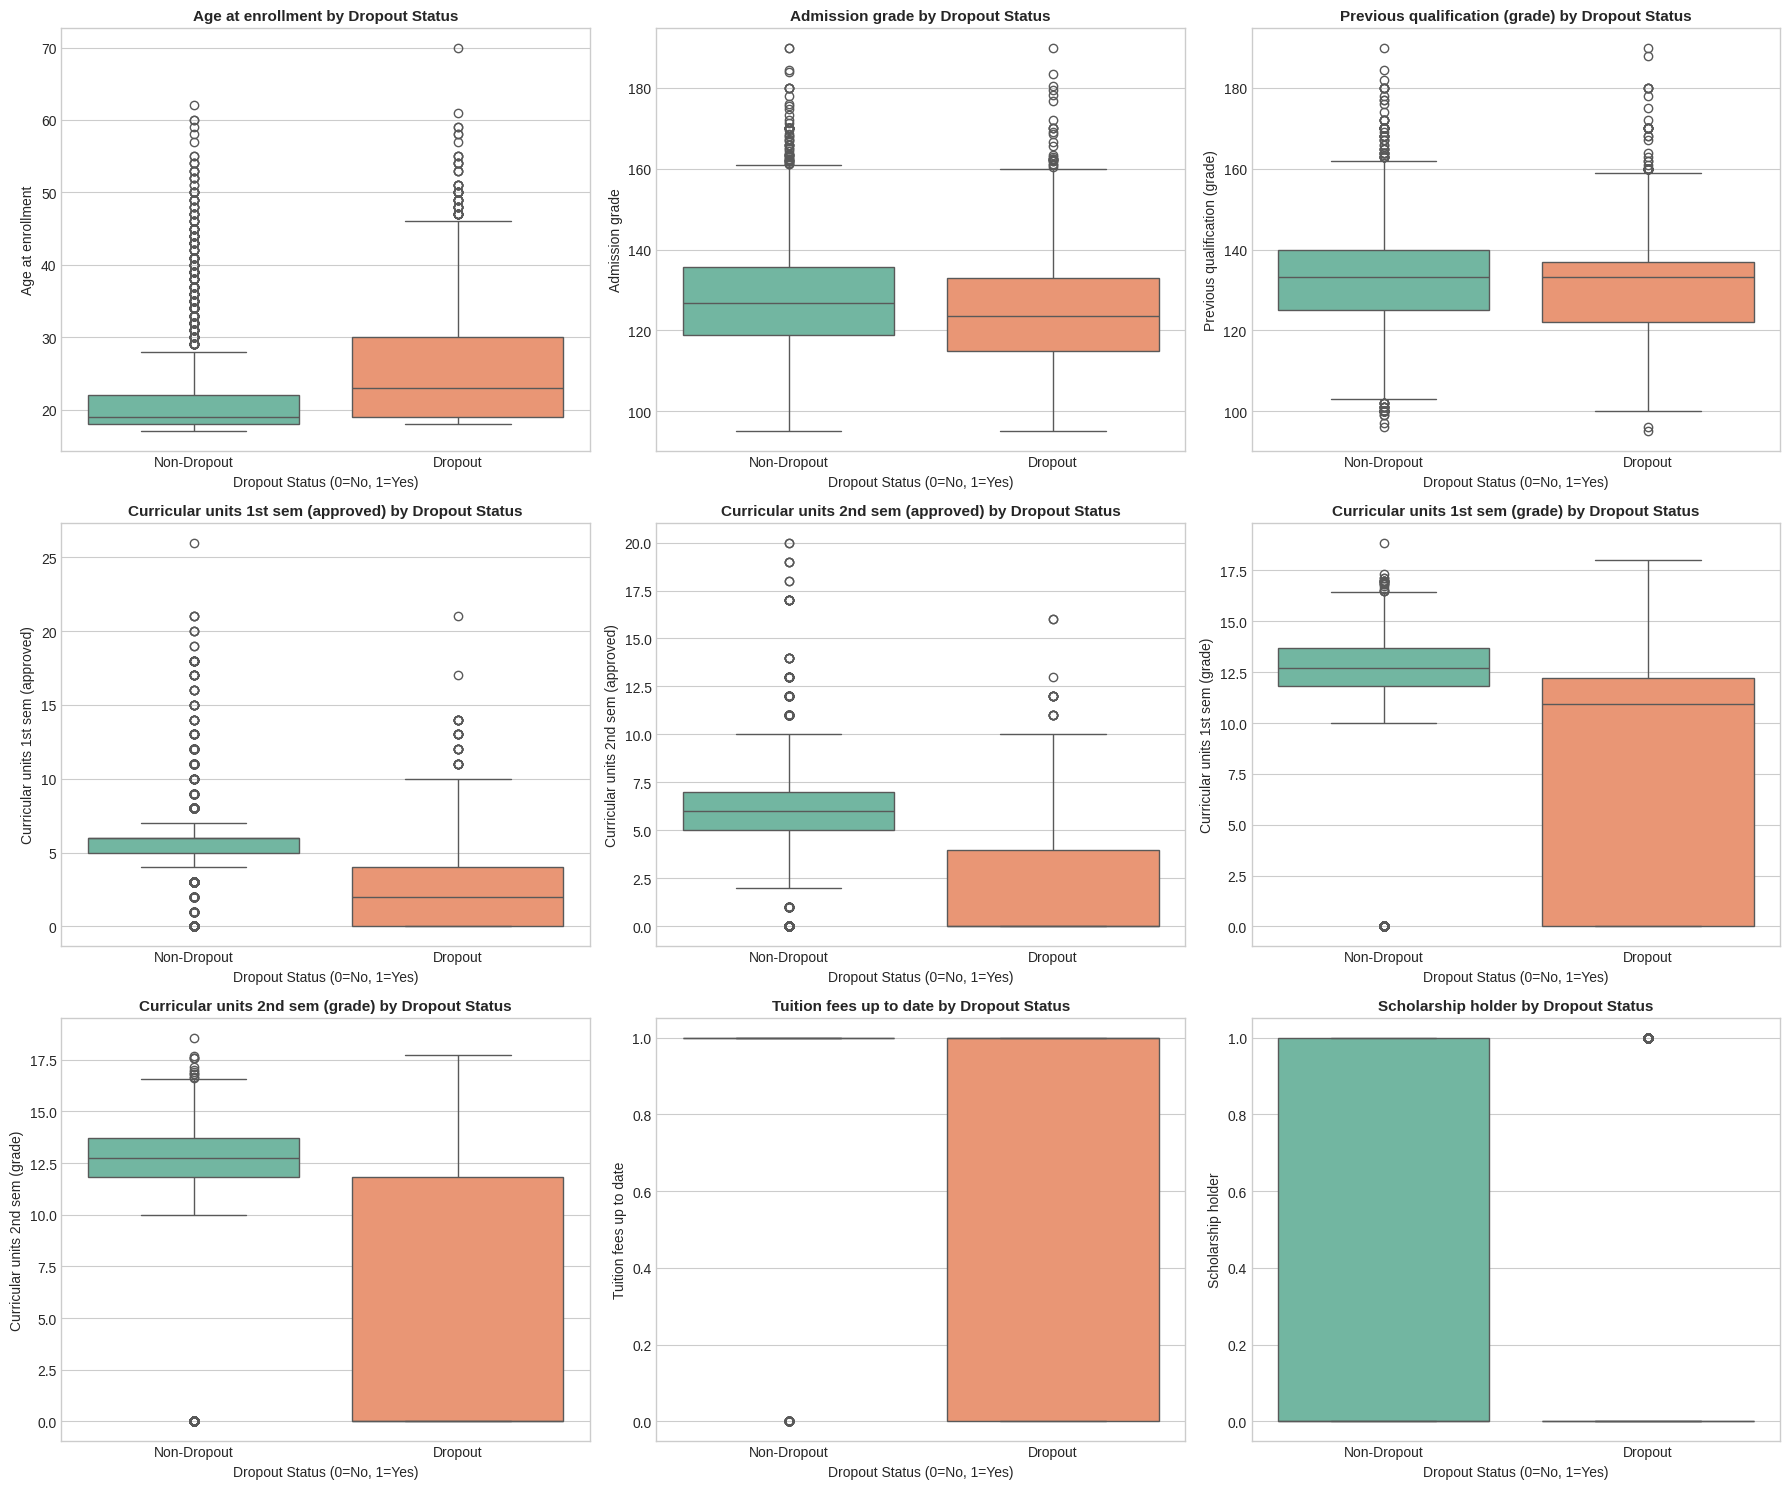


✅ EDA COMPLETE!


In [ ]:
print("\n" + "="*80)
print("STEP 1: DATA LOADING & EXPLORATORY DATA ANALYSIS")
print("="*80)

# Upload the dataset
from google.colab import files
print("\n📁 Please upload your data.csv file:")
uploaded = files.upload()

# Load the dataset
df = pd.read_csv('data.csv', delimiter=';')

print("\n" + "-"*80)
print("1.1 DATASET OVERVIEW")
print("-"*80)
print(f"Dataset Shape: {df.shape}")
print(f"Total Rows: {df.shape[0]:,}")
print(f"Total Columns: {df.shape[1]}")
print(f"\nColumn Names:")
for i, col in enumerate(df.columns, 1):
    print(f"  {i:2d}. {col}")

print("\n" + "-"*80)
print("1.2 FIRST 5 ROWS")
print("-"*80)
display(df.head())

print("\n" + "-"*80)
print("1.3 DATA TYPES & INFO")
print("-"*80)
df.info()

print("\n" + "-"*80)
print("1.4 STATISTICAL SUMMARY")
print("-"*80)
display(df.describe())

print("\n" + "-"*80)
print("1.5 MISSING VALUES ANALYSIS")
print("-"*80)
missing = df.isnull().sum()
missing_percent = (missing / len(df)) * 100
missing_df = pd.DataFrame({
    'Column': missing.index,
    'Missing_Count': missing.values,
    'Percentage': missing_percent.values
})
missing_df = missing_df[missing_df['Missing_Count'] > 0].sort_values('Missing_Count', ascending=False)

if len(missing_df) > 0:
    display(missing_df)

    # Visualize missing values
    plt.figure(figsize=(12, 6))
    plt.bar(missing_df['Column'], missing_df['Percentage'], color='coral')
    plt.xticks(rotation=45, ha='right')
    plt.xlabel('Columns', fontsize=12)
    plt.ylabel('Missing Percentage (%)', fontsize=12)
    plt.title('Missing Values by Column', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print("✅ No missing values found in the dataset!")

print("\n" + "-"*80)
print("1.6 TARGET VARIABLE ANALYSIS")
print("-"*80)

# Encode target if needed (Dropout = 1, others = 0)
target_counts = df['Target'].value_counts()
print("\nOriginal Target Distribution:")
print(target_counts)
print("\nTarget Percentages:")
print((target_counts / len(df) * 100).round(2))

# Binary encoding: Dropout vs Non-Dropout
df['Target_Binary'] = df['Target'].apply(lambda x: 1 if x == 'Dropout' else 0)

print("\nBinary Target Distribution:")
binary_counts = df['Target_Binary'].value_counts()
print(f"Non-Dropout (0): {binary_counts[0]:,} ({binary_counts[0]/len(df)*100:.2f}%)")
print(f"Dropout (1): {binary_counts[1]:,} ({binary_counts[1]/len(df)*100:.2f}%)")

# Visualizations
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Original target distribution
sns.countplot(data=df, x='Target', ax=axes[0], palette='Set2')
axes[0].set_title('Original Target Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Target Class', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)
for container in axes[0].containers:
    axes[0].bar_label(container, fontsize=10)

# Binary target distribution
sns.countplot(data=df, x='Target_Binary', ax=axes[1], palette='Set1')
axes[1].set_title('Binary Target Distribution', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Target (0=Non-Dropout, 1=Dropout)', fontsize=12)
axes[1].set_ylabel('Count', fontsize=12)
axes[1].set_xticklabels(['Non-Dropout', 'Dropout'])
for container in axes[1].containers:
    axes[1].bar_label(container, fontsize=10)

# Pie chart
colors = ['#66c2a5', '#fc8d62']
axes[2].pie(binary_counts.values, labels=['Non-Dropout', 'Dropout'],
            autopct='%1.1f%%', startangle=90, colors=colors,
            textprops={'fontsize': 12, 'fontweight': 'bold'})
axes[2].set_title('Dropout vs Non-Dropout Proportion', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

# Class imbalance check
imbalance_ratio = binary_counts.max() / binary_counts.min()
print(f"\n📊 Class Imbalance Ratio: {imbalance_ratio:.2f}:1")
if imbalance_ratio > 1.5:
    print("⚠️  WARNING: Significant class imbalance detected!")
    print("   → Will apply SMOTE oversampling during training")
else:
    print("✅ Classes are relatively balanced")

print("\n" + "-"*80)
print("1.7 FEATURE TYPE IDENTIFICATION")
print("-"*80)

# Separate numerical and categorical columns
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

# Remove target variables
if 'Target' in categorical_cols:
    categorical_cols.remove('Target')
if 'Target_Binary' in numerical_cols:
    numerical_cols.remove('Target_Binary')

print(f"\n📊 Numerical Features ({len(numerical_cols)}):")
for i, col in enumerate(numerical_cols, 1):
    print(f"  {i:2d}. {col}")

print(f"\n📝 Categorical Features ({len(categorical_cols)}):")
for i, col in enumerate(categorical_cols, 1):
    print(f"  {i:2d}. {col}")

print("\n" + "-"*80)
print("1.8 CORRELATION HEATMAP")
print("-"*80)

# Calculate correlation with target
corr_with_target = df[numerical_cols + ['Target_Binary']].corr()['Target_Binary'].sort_values(ascending=False)
print("\nTop 15 Features Correlated with Dropout:")
print(corr_with_target[1:16])  # Exclude Target_Binary itself

# Full correlation matrix
correlation_matrix = df[numerical_cols].corr()

# Plot heatmap
plt.figure(figsize=(20, 16))
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
sns.heatmap(correlation_matrix, mask=mask, annot=False, cmap='RdBu_r',
            center=0, linewidths=0.5, cbar_kws={"shrink": 0.8},
            vmin=-1, vmax=1)
plt.title('Correlation Heatmap of Numerical Features', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# Find highly correlated pairs
print("\n🔍 Highly Correlated Feature Pairs (|correlation| > 0.8):")
high_corr = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        if abs(correlation_matrix.iloc[i, j]) > 0.8:
            high_corr.append({
                'Feature_1': correlation_matrix.columns[i],
                'Feature_2': correlation_matrix.columns[j],
                'Correlation': round(correlation_matrix.iloc[i, j], 3)
            })

if high_corr:
    high_corr_df = pd.DataFrame(high_corr).sort_values('Correlation', key=abs, ascending=False)
    display(high_corr_df)
else:
    print("  No highly correlated pairs found.")

print("\n" + "-"*80)
print("1.9 KEY FEATURE DISTRIBUTIONS BY TARGET")
print("-"*80)

# Select key features for detailed analysis
key_features = [
    'Age at enrollment',
    'Admission grade',
    'Previous qualification (grade)',
    'Curricular units 1st sem (approved)',
    'Curricular units 2nd sem (approved)',
    'Curricular units 1st sem (grade)',
    'Curricular units 2nd sem (grade)',
    'Tuition fees up to date',
    'Scholarship holder'
]

# Filter features that exist
key_features = [f for f in key_features if f in df.columns]

# Create boxplots
n_features = len(key_features)
n_cols = 3
n_rows = (n_features + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5*n_rows))
axes = axes.flatten()

for idx, feature in enumerate(key_features):
    sns.boxplot(data=df, x='Target_Binary', y=feature, ax=axes[idx], palette='Set2')
    axes[idx].set_title(f'{feature} by Dropout Status', fontweight='bold', fontsize=11)
    axes[idx].set_xlabel('Dropout Status (0=No, 1=Yes)', fontsize=10)
    axes[idx].set_ylabel(feature, fontsize=10)
    axes[idx].set_xticklabels(['Non-Dropout', 'Dropout'])

# Hide unused subplots
for idx in range(n_features, len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

print("\n✅ EDA COMPLETE!")

##  STEP 2: DATA PREPROCESSING

In [ ]:
print("\n" + "="*80)
print("STEP 2: DATA PREPROCESSING")
print("="*80)

# Create a copy for preprocessing
df_processed = df.copy()

print("\n" + "-"*80)
print("2.1 HANDLING MISSING VALUES")
print("-"*80)

# Check missing values before imputation
missing_before = df_processed.isnull().sum().sum()
print(f"Total missing values before imputation: {missing_before}")

# Impute numerical columns with median
num_imputer = SimpleImputer(strategy='median')
if numerical_cols:
    df_processed[numerical_cols] = num_imputer.fit_transform(df_processed[numerical_cols])
    print(f"✅ Imputed {len(numerical_cols)} numerical columns with MEDIAN")

# Impute categorical columns with mode
cat_imputer = SimpleImputer(strategy='most_frequent')
if categorical_cols:
    df_processed[categorical_cols] = cat_imputer.fit_transform(df_processed[categorical_cols])
    print(f"✅ Imputed {len(categorical_cols)} categorical columns with MODE")

# Verify no missing values remain
missing_after = df_processed.isnull().sum().sum()
print(f"Total missing values after imputation: {missing_after}")

if missing_after == 0:
    print("✅ All missing values successfully handled!")

print("\n" + "-"*80)
print("2.2 ENCODING CATEGORICAL VARIABLES")
print("-"*80)

# For this dataset, most features are already numerical
# If there are categorical columns, one-hot encode them
if categorical_cols:
    print(f"Encoding {len(categorical_cols)} categorical features...")
    df_encoded = pd.get_dummies(df_processed, columns=categorical_cols, drop_first=True)
    print(f"✅ One-hot encoding complete!")
    print(f"   Original columns: {df_processed.shape[1]}")
    print(f"   After encoding: {df_encoded.shape[1]}")
else:
    df_encoded = df_processed.copy()
    print("ℹ️  No categorical columns to encode (all features are numerical)")

print("\n" + "-"*80)
print("2.3 FEATURE-TARGET SEPARATION")
print("-"*80)

# Separate features and target
X = df_encoded.drop(['Target', 'Target_Binary'], axis=1, errors='ignore')
y = df_encoded['Target_Binary']

print(f"Features (X) shape: {X.shape}")
print(f"Target (y) shape: {y.shape}")
print(f"Number of features: {X.shape[1]}")

# Store feature names for later use
feature_names = X.columns.tolist()
print(f"\nFeature names saved: {len(feature_names)} features")

print("\n" + "-"*80)
print("2.4 TRAIN-TEST SPLIT")
print("-"*80)

# Split data: 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape[0]:,} samples ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Test set: {X_test.shape[0]:,} samples ({X_test.shape[0]/len(X)*100:.1f}%)")
print(f"\nTrain set class distribution:")
print(y_train.value_counts())
print(f"\nTest set class distribution:")
print(y_test.value_counts())

print("\n" + "-"*80)
print("2.5 FEATURE SCALING (STANDARDIZATION)")
print("-"*80)

# Apply StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrame for easier handling
X_train_scaled = pd.DataFrame(X_train_scaled, columns=feature_names, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=feature_names, index=X_test.index)

print("✅ Features scaled using StandardScaler (mean=0, std=1)")
print(f"\nScaled training data shape: {X_train_scaled.shape}")
print(f"Scaled test data shape: {X_test_scaled.shape}")

# Show scaling effect
print("\nExample - Before and After Scaling (first feature):")
sample_feature = feature_names[0]
print(f"Feature: {sample_feature}")
print(f"  Original - Mean: {X_train[sample_feature].mean():.2f}, Std: {X_train[sample_feature].std():.2f}")
print(f"  Scaled   - Mean: {X_train_scaled[sample_feature].mean():.2f}, Std: {X_train_scaled[sample_feature].std():.2f}")

print("\n" + "-"*80)
print("2.6 HANDLING CLASS IMBALANCE WITH SMOTE")
print("-"*80)

# Apply SMOTE to balance classes
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_scaled, y_train)

print("Class distribution BEFORE SMOTE:")
print(y_train.value_counts())
print("\nClass distribution AFTER SMOTE:")
print(pd.Series(y_train_balanced).value_counts())
print(f"\n✅ Training set balanced: {len(X_train_balanced):,} samples")

print("\n✅ PREPROCESSING COMPLETE!")


STEP 2: DATA PREPROCESSING

--------------------------------------------------------------------------------
2.1 HANDLING MISSING VALUES
--------------------------------------------------------------------------------
Total missing values before imputation: 0
✅ Imputed 36 numerical columns with MEDIAN
Total missing values after imputation: 0
✅ All missing values successfully handled!

--------------------------------------------------------------------------------
2.2 ENCODING CATEGORICAL VARIABLES
--------------------------------------------------------------------------------
ℹ️  No categorical columns to encode (all features are numerical)

--------------------------------------------------------------------------------
2.3 FEATURE-TARGET SEPARATION
--------------------------------------------------------------------------------
Features (X) shape: (4424, 36)
Target (y) shape: (4424,)
Number of features: 36

Feature names saved: 36 features

----------------------------------------

## STEP 3: MODEL TRAINING & HYPERPARAMETER TUNING


STEP 3: MODEL TRAINING & CROSS-VALIDATION

--------------------------------------------------------------------------------
3.1 BASELINE MODEL TRAINING (5-FOLD CROSS-VALIDATION)
--------------------------------------------------------------------------------

🔄 Training Logistic Regression...
  5-Fold CV F1 Scores: [0.84778013 0.86602358 0.86602358 0.84874864 0.84165781]
  Mean F1: 0.8540 (+/- 0.0101)

🔄 Training Decision Tree...
  5-Fold CV F1 Scores: [0.84311633 0.8442623  0.85507246 0.87001024 0.83434343]
  Mean F1: 0.8494 (+/- 0.0122)

🔄 Training Random Forest...
  5-Fold CV F1 Scores: [0.89513514 0.90793651 0.90116897 0.9015873  0.89289502]
  Mean F1: 0.8997 (+/- 0.0053)

--------------------------------------------------------------------------------
BASELINE MODEL COMPARISON
--------------------------------------------------------------------------------


,Model,Mean F1-Score,Std Dev
2,Random Forest,0.899745,0.005305
0,Logistic Regression,0.854047,0.010077
1,Decision Tree,0.849361,0.012244


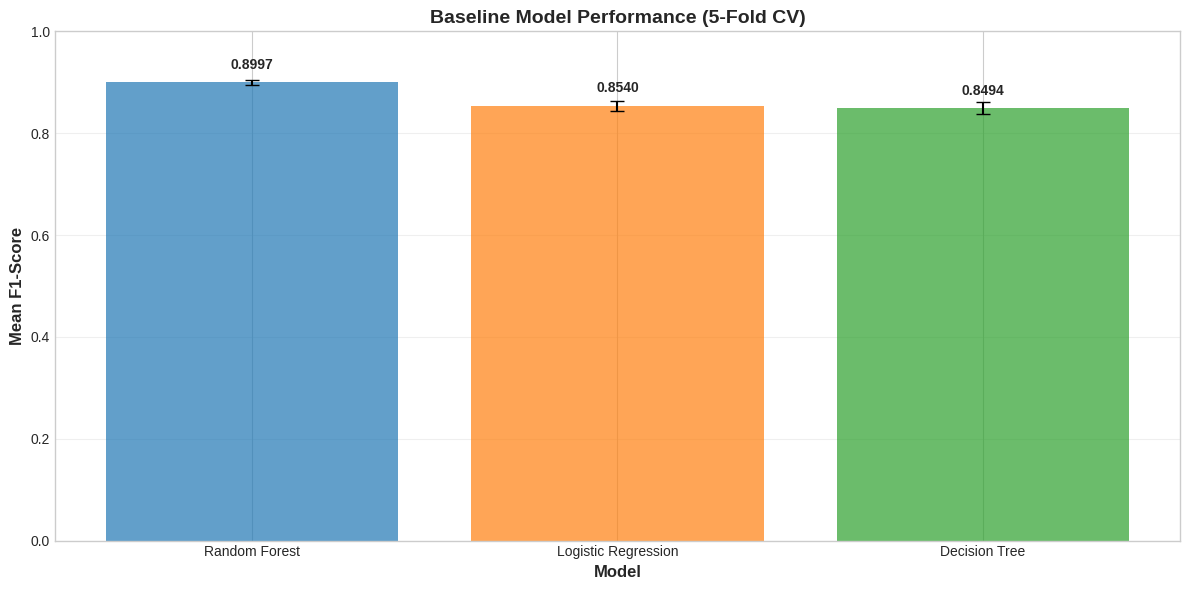


--------------------------------------------------------------------------------
3.2 HYPERPARAMETER TUNING
--------------------------------------------------------------------------------

🔍 Tuning Logistic Regression...
  ✅ Best Parameters: {'C': 10, 'penalty': 'l2', 'solver': 'lbfgs'}
  ✅ Best CV F1-Score: 0.8544

🔍 Tuning Decision Tree...
  ✅ Best Parameters: {'criterion': 'gini', 'max_depth': 7, 'min_samples_leaf': 1, 'min_samples_split': 5}
  ✅ Best CV F1-Score: 0.8621

🔍 Tuning Random Forest...
  ✅ Best Parameters: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}
  ✅ Best CV F1-Score: 0.9024

--------------------------------------------------------------------------------
HYPERPARAMETER TUNING SUMMARY
--------------------------------------------------------------------------------


,Model,Best F1-Score,Best Parameters
2,Random Forest,0.902446,"{'max_depth': None, 'min_samples_leaf': 1, 'mi..."
1,Decision Tree,0.862084,"{'criterion': 'gini', 'max_depth': 7, 'min_sam..."
0,Logistic Regression,0.854354,"{'C': 10, 'penalty': 'l2', 'solver': 'lbfgs'}"



✅ MODEL TRAINING COMPLETE!


In [ ]:
print("\n" + "="*80)
print("STEP 3: MODEL TRAINING & CROSS-VALIDATION")
print("="*80)

# Initialize models
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42)
}

print("\n" + "-"*80)
print("3.1 BASELINE MODEL TRAINING (5-FOLD CROSS-VALIDATION)")
print("-"*80)

# Cross-validation setup
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Store baseline results
baseline_results = {}

for name, model in models.items():
    print(f"\n🔄 Training {name}...")

    # Perform cross-validation
    cv_scores = cross_val_score(model, X_train_balanced, y_train_balanced,
                                 cv=cv, scoring='f1', n_jobs=-1)

    baseline_results[name] = {
        'mean_f1': cv_scores.mean(),
        'std_f1': cv_scores.std(),
        'cv_scores': cv_scores
    }

    print(f"  5-Fold CV F1 Scores: {cv_scores}")
    print(f"  Mean F1: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

# Display baseline comparison
print("\n" + "-"*80)
print("BASELINE MODEL COMPARISON")
print("-"*80)
baseline_df = pd.DataFrame({
    'Model': list(baseline_results.keys()),
    'Mean F1-Score': [baseline_results[m]['mean_f1'] for m in baseline_results],
    'Std Dev': [baseline_results[m]['std_f1'] for m in baseline_results]
}).sort_values('Mean F1-Score', ascending=False)

display(baseline_df)

# Visualize baseline results
plt.figure(figsize=(12, 6))
x_pos = np.arange(len(baseline_df))
plt.bar(x_pos, baseline_df['Mean F1-Score'], yerr=baseline_df['Std Dev'],
        capsize=5, alpha=0.7, color=['#1f77b4', '#ff7f0e', '#2ca02c'])
plt.xlabel('Model', fontsize=12, fontweight='bold')
plt.ylabel('Mean F1-Score', fontsize=12, fontweight='bold')
plt.title('Baseline Model Performance (5-Fold CV)', fontsize=14, fontweight='bold')
plt.xticks(x_pos, baseline_df['Model'])
plt.ylim([0, 1])
plt.grid(axis='y', alpha=0.3)
for i, v in enumerate(baseline_df['Mean F1-Score']):
    plt.text(i, v + 0.02, f'{v:.4f}', ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.show()

print("\n" + "-"*80)
print("3.2 HYPERPARAMETER TUNING")
print("-"*80)

# Define parameter grids
param_grids = {
    'Logistic Regression': {
        'C': [0.01, 0.1, 1, 10, 100],
        'penalty': ['l2'],
        'solver': ['lbfgs']
    },
    'Decision Tree': {
        'max_depth': [3, 5, 7, 10, 15, 20, None],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4],
        'criterion': ['gini', 'entropy']
    },
    'Random Forest': {
        'n_estimators': [50, 100, 200, 300],
        'max_depth': [5, 10, 15, 20, None],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4]
    }
}

# Perform GridSearchCV
tuned_models = {}
tuning_results = {}

for name, model in models.items():
    print(f"\n🔍 Tuning {name}...")

    grid_search = GridSearchCV(
        estimator=model,
        param_grid=param_grids[name],
        cv=cv,
        scoring='f1',
        n_jobs=-1,
        verbose=0
    )

    grid_search.fit(X_train_balanced, y_train_balanced)

    tuned_models[name] = grid_search.best_estimator_
    tuning_results[name] = {
        'best_params': grid_search.best_params_,
        'best_f1': grid_search.best_score_,
        'cv_results': grid_search.cv_results_
    }

    print(f"  ✅ Best Parameters: {grid_search.best_params_}")
    print(f"  ✅ Best CV F1-Score: {grid_search.best_score_:.4f}")

print("\n" + "-"*80)
print("HYPERPARAMETER TUNING SUMMARY")
print("-"*80)

tuning_summary = pd.DataFrame({
    'Model': list(tuning_results.keys()),
    'Best F1-Score': [tuning_results[m]['best_f1'] for m in tuning_results],
    'Best Parameters': [str(tuning_results[m]['best_params']) for m in tuning_results]
}).sort_values('Best F1-Score', ascending=False)

display(tuning_summary)

print("\n✅ MODEL TRAINING COMPLETE!")

## STEP 4: MODEL EVALUATION


STEP 4: MODEL EVALUATION ON TEST SET

--------------------------------------------------------------------------------
4.1 PREDICTIONS ON TEST SET
--------------------------------------------------------------------------------

📊 Evaluating Logistic Regression...
  Accuracy:  0.8734
  Precision: 0.7867
  Recall:    0.8310
  F1-Score:  0.8082
  AUC-ROC:   0.9258

📊 Evaluating Decision Tree...
  Accuracy:  0.8542
  Precision: 0.7798
  Recall:    0.7606
  F1-Score:  0.7701
  AUC-ROC:   0.8672

📊 Evaluating Random Forest...
  Accuracy:  0.8893
  Precision: 0.8550
  Recall:    0.7887
  F1-Score:  0.8205
  AUC-ROC:   0.9324

--------------------------------------------------------------------------------
4.2 MODEL COMPARISON TABLE
--------------------------------------------------------------------------------


,Model,Accuracy,Precision,Recall,F1-Score,AUC-ROC
2,Random Forest,0.889266,0.854962,0.788732,0.820513,0.932413
0,Logistic Regression,0.873446,0.786667,0.830986,0.808219,0.925845
1,Decision Tree,0.854237,0.779783,0.760563,0.770053,0.867225


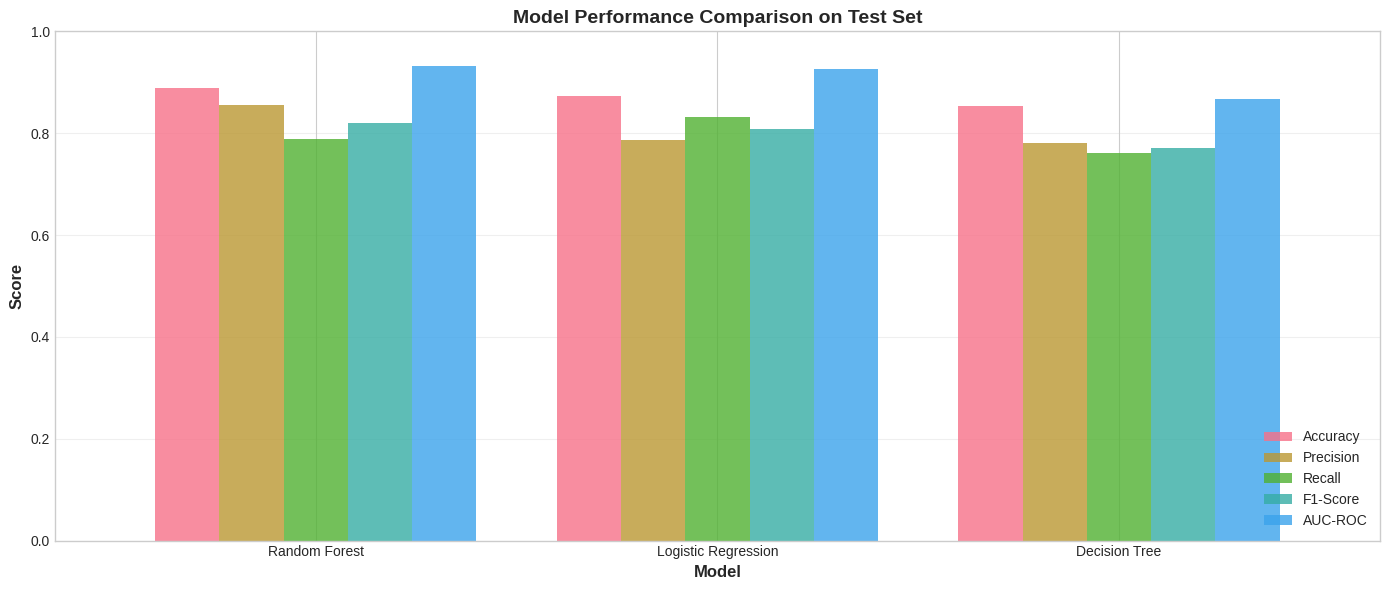


--------------------------------------------------------------------------------
4.3 CLASSIFICATION REPORTS
--------------------------------------------------------------------------------

Logistic Regression - Classification Report
              precision    recall  f1-score   support

 Non-Dropout     0.9179    0.8935    0.9056       601
     Dropout     0.7867    0.8310    0.8082       284

    accuracy                         0.8734       885
   macro avg     0.8523    0.8622    0.8569       885
weighted avg     0.8758    0.8734    0.8743       885


Decision Tree - Classification Report
              precision    recall  f1-score   support

 Non-Dropout     0.8882    0.8985    0.8933       601
     Dropout     0.7798    0.7606    0.7701       284

    accuracy                         0.8542       885
   macro avg     0.8340    0.8295    0.8317       885
weighted avg     0.8534    0.8542    0.8537       885


Random Forest - Classification Report
              precision    recall

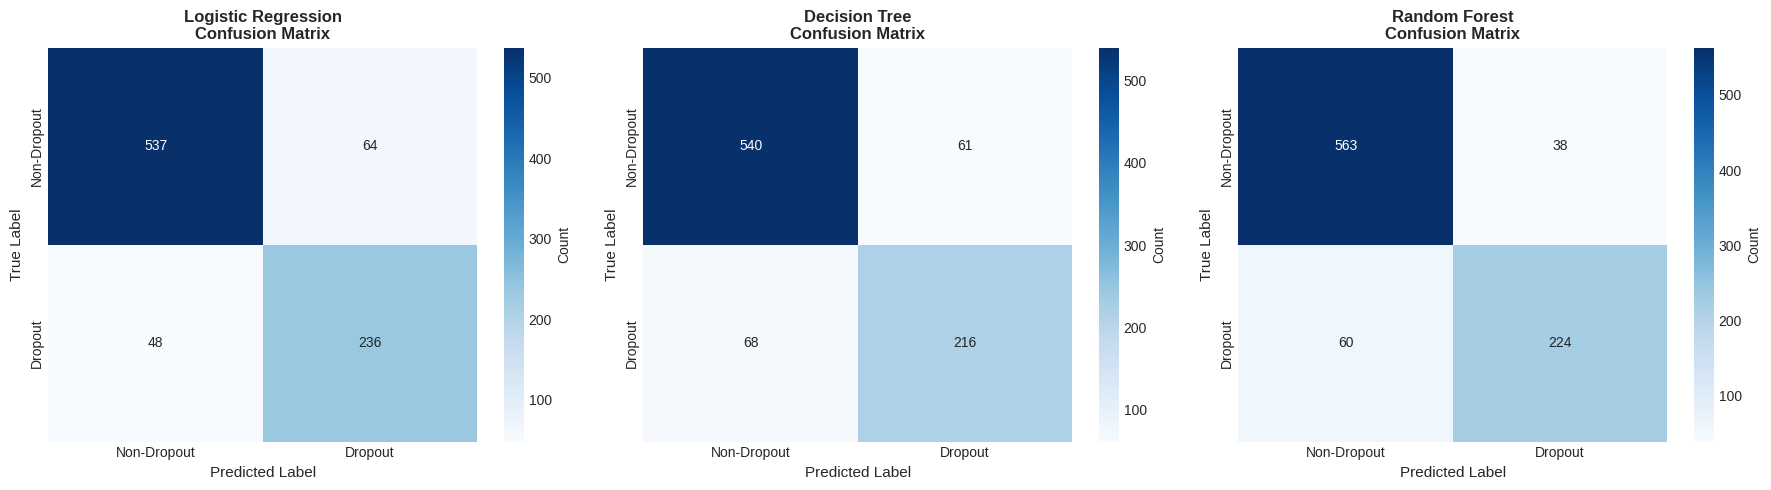


--------------------------------------------------------------------------------
4.5 ROC CURVES
--------------------------------------------------------------------------------


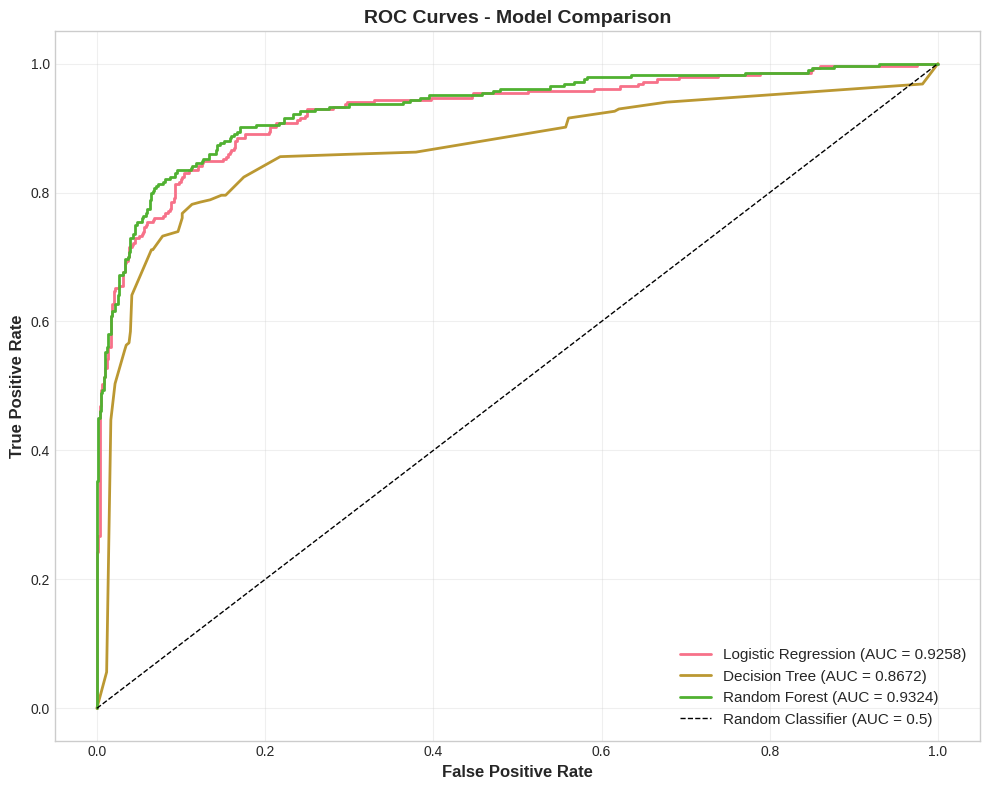


--------------------------------------------------------------------------------
4.6 FEATURE IMPORTANCE (RANDOM FOREST)
--------------------------------------------------------------------------------

Top 20 Most Important Features:


,Feature,Importance
30,Curricular units 2nd sem (approved),0.189757
24,Curricular units 1st sem (approved),0.104969
31,Curricular units 2nd sem (grade),0.096934
25,Curricular units 1st sem (grade),0.062107
16,Tuition fees up to date,0.051191
19,Age at enrollment,0.040582
29,Curricular units 2nd sem (evaluations),0.034811
3,Course,0.029213
1,Application mode,0.029045
12,Admission grade,0.026672


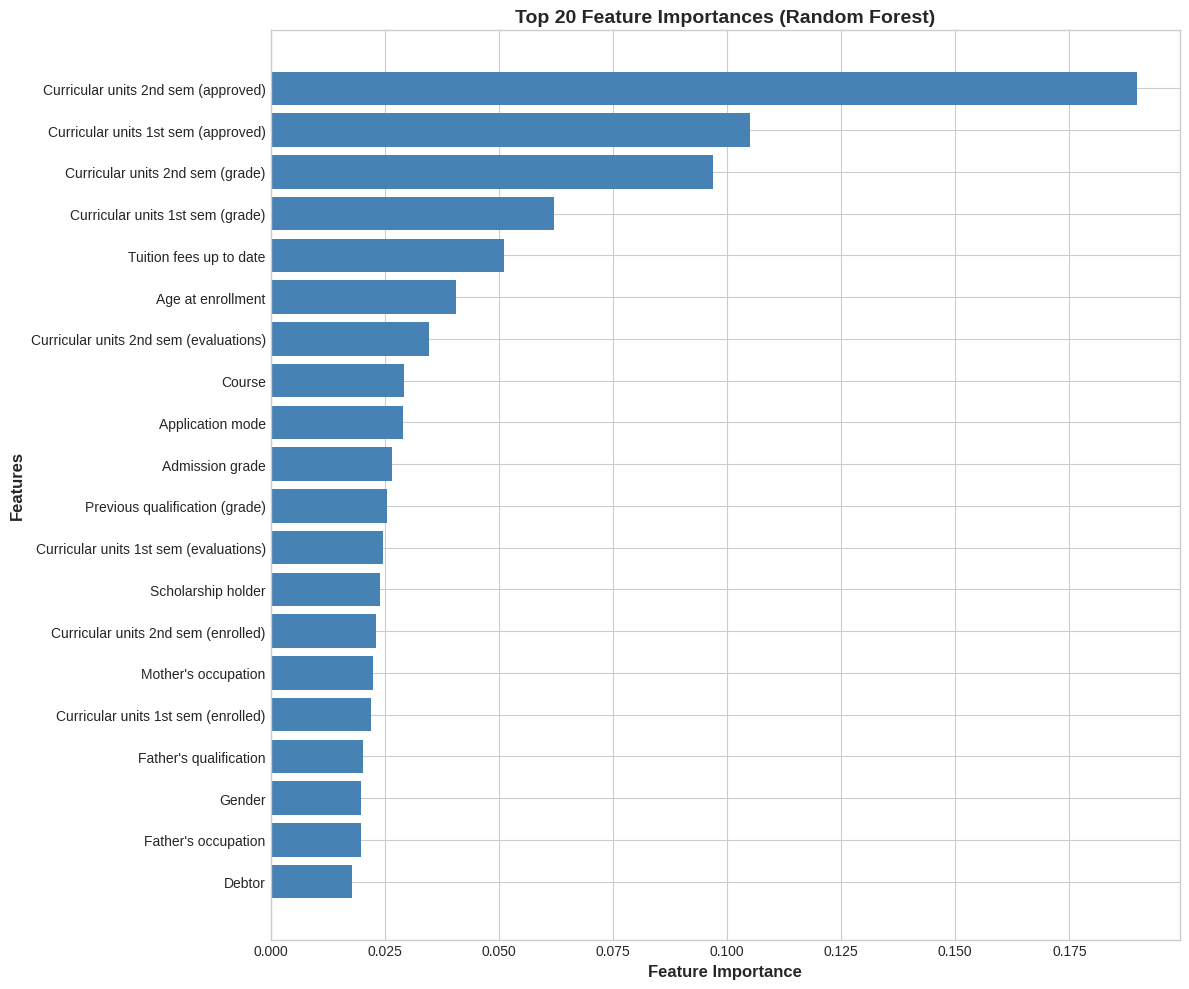


✅ EVALUATION COMPLETE!


In [ ]:
print("\n" + "="*80)
print("STEP 4: MODEL EVALUATION ON TEST SET")
print("="*80)

# Store test results
test_results = {}

print("\n" + "-"*80)
print("4.1 PREDICTIONS ON TEST SET")
print("-"*80)

for name, model in tuned_models.items():
    print(f"\n📊 Evaluating {name}...")

    # Predictions
    y_pred = model.predict(X_test_scaled)
    y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]

    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc_roc = roc_auc_score(y_test, y_pred_proba)

    test_results[name] = {
        'y_pred': y_pred,
        'y_pred_proba': y_pred_proba,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'auc_roc': auc_roc
    }

    print(f"  Accuracy:  {accuracy:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall:    {recall:.4f}")
    print(f"  F1-Score:  {f1:.4f}")
    print(f"  AUC-ROC:   {auc_roc:.4f}")

print("\n" + "-"*80)
print("4.2 MODEL COMPARISON TABLE")
print("-"*80)

comparison_df = pd.DataFrame({
    'Model': list(test_results.keys()),
    'Accuracy': [test_results[m]['accuracy'] for m in test_results],
    'Precision': [test_results[m]['precision'] for m in test_results],
    'Recall': [test_results[m]['recall'] for m in test_results],
    'F1-Score': [test_results[m]['f1'] for m in test_results],
    'AUC-ROC': [test_results[m]['auc_roc'] for m in test_results]
}).sort_values('F1-Score', ascending=False)

display(comparison_df.style.highlight_max(axis=0, props='background-color: lightgreen; font-weight: bold'))

# Visualize comparison
fig, ax = plt.subplots(figsize=(14, 6))
comparison_df.set_index('Model')[['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC']].plot(
    kind='bar', ax=ax, width=0.8, alpha=0.8
)
ax.set_ylabel('Score', fontsize=12, fontweight='bold')
ax.set_xlabel('Model', fontsize=12, fontweight='bold')
ax.set_title('Model Performance Comparison on Test Set', fontsize=14, fontweight='bold')
ax.set_ylim([0, 1])
ax.legend(loc='lower right', fontsize=10)
ax.grid(axis='y', alpha=0.3)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print("\n" + "-"*80)
print("4.3 CLASSIFICATION REPORTS")
print("-"*80)

for name, model in tuned_models.items():
    print(f"\n{'='*60}")
    print(f"{name} - Classification Report")
    print('='*60)
    y_pred = test_results[name]['y_pred']
    print(classification_report(y_test, y_pred,
                                target_names=['Non-Dropout', 'Dropout'],
                                digits=4))

print("\n" + "-"*80)
print("4.4 CONFUSION MATRICES")
print("-"*80)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (name, model) in enumerate(tuned_models.items()):
    y_pred = test_results[name]['y_pred']
    cm = confusion_matrix(y_test, y_pred)

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                xticklabels=['Non-Dropout', 'Dropout'],
                yticklabels=['Non-Dropout', 'Dropout'],
                cbar_kws={'label': 'Count'})
    axes[idx].set_title(f'{name}\nConfusion Matrix', fontweight='bold', fontsize=12)
    axes[idx].set_ylabel('True Label', fontsize=11)
    axes[idx].set_xlabel('Predicted Label', fontsize=11)

plt.tight_layout()
plt.show()

print("\n" + "-"*80)
print("4.5 ROC CURVES")
print("-"*80)

plt.figure(figsize=(10, 8))

for name in tuned_models.keys():
    y_pred_proba = test_results[name]['y_pred_proba']
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    auc = test_results[name]['auc_roc']

    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.4f})', linewidth=2)

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier (AUC = 0.5)', linewidth=1)
plt.xlabel('False Positive Rate', fontsize=12, fontweight='bold')
plt.ylabel('True Positive Rate', fontsize=12, fontweight='bold')
plt.title('ROC Curves - Model Comparison', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("\n" + "-"*80)
print("4.6 FEATURE IMPORTANCE (RANDOM FOREST)")
print("-"*80)

# Get Random Forest model
rf_model = tuned_models['Random Forest']

# Extract feature importances
feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nTop 20 Most Important Features:")
display(feature_importance.head(20))

# Plot top 20 features
plt.figure(figsize=(12, 10))
top_features = feature_importance.head(20)
plt.barh(range(len(top_features)), top_features['Importance'], color='steelblue')
plt.yticks(range(len(top_features)), top_features['Feature'])
plt.xlabel('Feature Importance', fontsize=12, fontweight='bold')
plt.ylabel('Features', fontsize=12, fontweight='bold')
plt.title('Top 20 Feature Importances (Random Forest)', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("\n✅ EVALUATION COMPLETE!")

## STEP 5: MODEL EXPORT & PREPARATION FOR GUI

In [ ]:
print("\n" + "="*80)
print("STEP 5: MODEL EXPORT FOR GUI DEPLOYMENT")
print("="*80)

# Select best model based on F1-score
best_model_name = comparison_df.iloc[0]['Model']
best_model = tuned_models[best_model_name]

print(f"\n🏆 Best Model: {best_model_name}")
print(f"   F1-Score: {comparison_df.iloc[0]['F1-Score']:.4f}")
print(f"   AUC-ROC: {comparison_df.iloc[0]['AUC-ROC']:.4f}")

# Save model, scaler, and feature names
print("\n💾 Saving model artifacts...")

artifacts = {
    'model': best_model,
    'scaler': scaler,
    'feature_names': feature_names,
    'model_name': best_model_name,
    'performance_metrics': {
        'accuracy': test_results[best_model_name]['accuracy'],
        'precision': test_results[best_model_name]['precision'],
        'recall': test_results[best_model_name]['recall'],
        'f1_score': test_results[best_model_name]['f1'],
        'auc_roc': test_results[best_model_name]['auc_roc']
    },
    'feature_importance': feature_importance.to_dict('records')
}

# Save to pickle file
with open('student_dropout_model.pkl', 'wb') as f:
    pickle.dump(artifacts, f)

print("✅ Model saved as 'student_dropout_model.pkl'")

# Download the model file
print("\n📥 Downloading model file...")
files.download('student_dropout_model.pkl')

print("\n" + "="*80)
print("🎉 ALL STEPS COMPLETED SUCCESSFULLY!")
print("="*80)
print("\nSummary:")
print("  ✅ Step 1: EDA - Complete")
print("  ✅ Step 2: Preprocessing - Complete")
print("  ✅ Step 3: Model Training - Complete")
print("  ✅ Step 4: Evaluation - Complete")
print("  ✅ Step 5: Model Export - Complete")
print("\nNext: Deploy the GUI using Streamlit")
print("="*80)


STEP 5: MODEL EXPORT FOR GUI DEPLOYMENT

🏆 Best Model: Random Forest
   F1-Score: 0.8205
   AUC-ROC: 0.9324

💾 Saving model artifacts...
✅ Model saved as 'student_dropout_model.pkl'

📥 Downloading model file...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


🎉 ALL STEPS COMPLETED SUCCESSFULLY!

Summary:
  ✅ Step 1: EDA - Complete
  ✅ Step 2: Preprocessing - Complete
  ✅ Step 3: Model Training - Complete
  ✅ Step 4: Evaluation - Complete
  ✅ Step 5: Model Export - Complete

Next: Deploy the GUI using Streamlit
